# Notebook 03 — Balanceo y comparación de los 12 modelos

**Proyecto final de Fundamentos de Inteligencia Artificial · Universidad EIA (2026-2)**

Aquí evaluamos todas las combinaciones de **modelo y estrategia de balanceo** con validación cruzada, y dejamos una tabla con el ranking. Comparamos los 12 modelos vistos en clase (8 individuales y 4 ensambles) con 4 estrategias: sin balanceo, `class_weight='balanced'`, SMOTE y submuestreo aleatorio. `class_weight` solo existe en 5 de los modelos, así que en total son 41 combinaciones.

Usamos el escalador y los rasgos que decidimos en el notebook 02, y solo leemos `data/train.csv`: **el conjunto de test no se toca**. El escalador y el balanceo van dentro del pipeline, para que se ajusten solo con la parte de entrenamiento de cada partición; si hiciéramos SMOTE antes de la validación cruzada, los resultados saldrían inflados.

Deja listo `resultados/comparacion_modelos.csv`, que lee el notebook 04.

In [3]:
# Si corremos en Google Colab ponemos True; en el computador (VS Code), False
EN_COLAB = False

if EN_COLAB:
    # En Colab hay que instalar lo que no viene de fábrica, y se repite en cada sesión nueva
    !pip install phik shap gradio imbalanced-learn -q
    # En Colab los archivos viven en Drive, así que primero lo montamos
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Proyecto_Sismos/'
else:
    RUTA_BASE = './'

# Todas las rutas del notebook salen de aquí, para no tener rutas regadas por el código
RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_RESULTADOS = RUTA_BASE + 'resultados/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

In [4]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)

# Por si las carpetas de salida no existen (por ejemplo, en una carpeta nueva de Drive)
os.makedirs(RUTA_RESULTADOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

## Cargar los datos y las decisiones del notebook 02

Leemos `train.csv` y el archivo con las decisiones de preprocesamiento (el escalador y la lista de rasgos). `X_train` queda solo con los rasgos elegidos, y `y_train` es la clase.

In [5]:
train = pd.read_csv(RUTA_DATOS + 'train.csv')
decisiones = joblib.load(RUTA_MODELOS + 'decisiones_preprocesamiento.joblib')

X_train = train[decisiones['rasgos']]
y_train = train['class']

print('Escalador:', decisiones['escalador'])
print('Rasgos:', decisiones['rasgos'])
print('X_train:', X_train.shape, '| turnos peligrosos:', y_train.sum(), '(' + str(round(y_train.mean() * 100, 2)) + '%)')

Escalador: MinMaxScaler
Rasgos: ['gpuls', 'nbumps', 'nbumps2', 'nbumps3', 'energy']
X_train: (2062, 5) | turnos peligrosos: 136 (6.6%)


Copiamos, **idénticos al notebook 02**, la validación cruzada, las métricas y la función `evaluar_cv`. Las métricas que reportamos son accuracy, precisión, recall, F1 y ROC AUC; la que manda es el F1 de la clase peligrosa.

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Con tan pocos turnos peligrosos, a veces un modelo no predice ninguno en una partición y la precisión
# queda indefinida (scikit-learn lanza una advertencia). Con zero_division=0 la contamos como 0 y seguimos.
metricas = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

def evaluar_cv(pipeline, X, y, nombre):
    """
    Evalúa un pipeline con validación cruzada estratificada de 10 particiones.
    Devuelve un diccionario con el promedio de cada métrica, la desviación del F1, el F1 de cada
    partición (para los box plots) y el tiempo que tardó. Se agrega a la lista rows para armar la tabla.
    """
    inicio = time.time()
    resultados = cross_validate(pipeline, X, y, cv=cv, scoring=metricas, n_jobs=-1)
    return {
        'Nombre': nombre,
        'Accuracy': resultados['test_accuracy'].mean(),
        'Precision': resultados['test_precision'].mean(),
        'Recall': resultados['test_recall'].mean(),
        'F1': resultados['test_f1'].mean(),
        'F1_std': resultados['test_f1'].std(),
        'ROC_AUC': resultados['test_roc_auc'].mean(),
        'F1_por_particion': resultados['test_f1'],
        'Tiempo_s': time.time() - inicio,
    }

## Catálogo de modelos

Los 12 modelos van en una función que devuelve una lista de parejas (nombre, modelo sin entrenar). Si queremos probar otro modelo, basta con agregar una línea aquí y el resto del notebook no cambia. Son los mismos que vimos en clase: 8 individuales y 4 ensambles. No les ponemos `n_jobs=-1` porque la validación cruzada ya corre en paralelo y se estorbarían entre sí.

In [7]:
def crear_modelos():
    """
    Devuelve los 12 modelos que comparamos, como parejas (nombre, modelo sin entrenar).
    Son los mismos que vimos en clase. Si queremos probar otro, basta con agregar una línea aquí;
    el resto del notebook no cambia.
    """
    modelos = [
        ('KNN', KNeighborsClassifier(n_neighbors=5)),
        ('Naive Bayes', GaussianNB()),
        ('Árbol de decisión', DecisionTreeClassifier(random_state=42)),
        ('Regresión logística', LogisticRegression(max_iter=2000, random_state=42)),
        ('SVM', SVC(random_state=42)),
        ('SVM lineal', LinearSVC(max_iter=10000, random_state=42)),
        ('Red neuronal (MLP)', MLPClassifier(max_iter=1000, random_state=42)),
        ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('Bagging', BaggingClassifier(random_state=42)),
        ('AdaBoost', AdaBoostClassifier(random_state=42)),
        ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
        ('Stacking', StackingClassifier(
            estimators=[('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                        ('svm', SVC(random_state=42)),
                        ('knn', KNeighborsClassifier(n_neighbors=5))],
            final_estimator=LogisticRegression(max_iter=2000),
            cv=5)),
    ]
    return modelos

lista_modelos = crear_modelos()
print(len(lista_modelos), 'modelos en el catálogo')

12 modelos en el catálogo


## Escalador, estrategias de balanceo y pipeline

Armamos tres funciones. `crear_escalador` devuelve un escalador nuevo según el nombre que guardamos en el notebook 02. `admite_class_weight` dice si un modelo tiene el parámetro `class_weight`: KNN, Naive Bayes, MLP, Bagging, AdaBoost, Gradient Boosting y Stacking no lo tienen, así que con ellos esa estrategia se salta (no es que se nos haya olvidado). `crear_pipeline` arma el pipeline de una combinación: escalador, luego SMOTE o submuestreo si toca, y al final el modelo. Usamos el `Pipeline` de `imblearn` porque así el balanceo se hace solo con los datos de entrenamiento de cada partición y nunca con los de validación.

In [8]:
ESTRATEGIAS = ['Sin balanceo', 'class_weight', 'SMOTE', 'Submuestreo']

def crear_escalador(nombre):
    """Devuelve un escalador nuevo según el nombre que guardamos en el notebook 02."""
    if nombre == 'MinMaxScaler':
        return MinMaxScaler()
    elif nombre == 'StandardScaler':
        return StandardScaler()
    return 'passthrough'   # 'Sin escalar': el pipeline deja pasar los datos tal cual

def admite_class_weight(modelo):
    """
    Dice si el modelo tiene el parámetro class_weight. KNN, Naive Bayes, MLP, Bagging, AdaBoost,
    Gradient Boosting y Stacking no lo tienen, así que con ellos esa estrategia no aplica.
    """
    return 'class_weight' in modelo.get_params()

def crear_pipeline(modelo, estrategia, nombre_escalador):
    """
    Arma el pipeline de una combinación modelo + estrategia: escalador -> (SMOTE o submuestreo) -> modelo.
    Usamos el Pipeline de imblearn porque así el balanceo se hace solo con los datos de entrenamiento
    de cada partición y nunca con los de validación; si no, los resultados saldrían inflados.
    """
    modelo = clone(modelo)   # copia limpia, para que una combinación no afecte a la siguiente
    pasos = [('escalador', crear_escalador(nombre_escalador))]
    if estrategia == 'SMOTE':
        pasos.append(('balanceo', SMOTE(random_state=42)))
    elif estrategia == 'Submuestreo':
        pasos.append(('balanceo', RandomUnderSampler(random_state=42)))
    elif estrategia == 'class_weight':
        modelo.set_params(class_weight='balanced')
    pasos.append(('clf', modelo))
    return ImbPipeline(pasos)

# Contamos cuántas combinaciones vamos a evaluar: 12 modelos x 3 estrategias + class_weight en los que la admiten
n_combinaciones = 0
for nombre_modelo, modelo in crear_modelos():
    for estrategia in ESTRATEGIAS:
        if estrategia == 'class_weight' and not admite_class_weight(modelo):
            continue
        n_combinaciones = n_combinaciones + 1
print('Combinaciones a evaluar:', n_combinaciones)

Combinaciones a evaluar: 41


**Lo que notamos.** El catálogo tiene los 12 modelos y salen **41 combinaciones**, como esperábamos: 12 modelos por 3 estrategias son 36, más 5 combinaciones con `class_weight`. Esa estrategia solo existe en el árbol de decisión, la regresión logística, la SVM, la SVM lineal y el Random Forest; en los otros siete modelos esa casilla queda vacía a propósito.

## Comparación de las combinaciones

Recorremos todos los modelos y todas las estrategias con dos ciclos `for` y guardamos una fila por combinación en `rows`. Stacking es el más lento, y puede tardar varios minutos. Es probable que scikit-learn lance advertencias (por ejemplo, de convergencia en la red neuronal o de precisión indefinida); son esperables con tan pocos turnos peligrosos y no las ocultamos.

In [9]:
rows = []
for nombre_modelo, modelo in crear_modelos():
    for estrategia in ESTRATEGIAS:
        if estrategia == 'class_weight' and not admite_class_weight(modelo):
            continue   # esta combinación no existe; lo explicamos en el markdown
        pipeline = crear_pipeline(modelo, estrategia, decisiones['escalador'])
        fila = evaluar_cv(pipeline, X_train, y_train, nombre_modelo + ' | ' + estrategia)
        fila['Modelo'] = nombre_modelo
        fila['Estrategia'] = estrategia
        rows.append(fila)
        print(nombre_modelo, '|', estrategia, '-> F1 =', round(fila['F1'], 3), '| tiempo:', round(fila['Tiempo_s']), 's')

tabla_modelos = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)
print('\nCombinaciones evaluadas:', len(tabla_modelos))

KNN | Sin balanceo -> F1 = 0.187 | tiempo: 11 s
KNN | SMOTE -> F1 = 0.199 | tiempo: 3 s
KNN | Submuestreo -> F1 = 0.231 | tiempo: 0 s
Naive Bayes | Sin balanceo -> F1 = 0.287 | tiempo: 0 s
Naive Bayes | SMOTE -> F1 = 0.303 | tiempo: 0 s
Naive Bayes | Submuestreo -> F1 = 0.309 | tiempo: 0 s
Árbol de decisión | Sin balanceo -> F1 = 0.181 | tiempo: 0 s
Árbol de decisión | class_weight -> F1 = 0.185 | tiempo: 0 s
Árbol de decisión | SMOTE -> F1 = 0.162 | tiempo: 0 s
Árbol de decisión | Submuestreo -> F1 = 0.172 | tiempo: 0 s
Regresión logística | Sin balanceo -> F1 = 0.028 | tiempo: 0 s
Regresión logística | class_weight -> F1 = 0.286 | tiempo: 0 s
Regresión logística | SMOTE -> F1 = 0.279 | tiempo: 0 s
Regresión logística | Submuestreo -> F1 = 0.298 | tiempo: 0 s
SVM | Sin balanceo -> F1 = 0.04 | tiempo: 0 s
SVM | class_weight -> F1 = 0.265 | tiempo: 1 s
SVM | SMOTE -> F1 = 0.27 | tiempo: 1 s
SVM | Submuestreo -> F1 = 0.29 | tiempo: 0 s
SVM lineal | Sin balanceo -> F1 = 0.0 | tiempo: 0 s


In [10]:
# La columna F1_por_particion (un arreglo por fila) no se guarda en el CSV; se usa aparte para los box plots
columnas_tabla = ['Modelo', 'Estrategia', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy', 'Tiempo_s']
tabla_modelos[columnas_tabla].to_csv(RUTA_RESULTADOS + 'comparacion_modelos.csv', index=False)
tabla_modelos[columnas_tabla]

,Modelo,Estrategia,F1,F1_std,Recall,Precision,ROC_AUC,Accuracy,Tiempo_s
0,Naive Bayes,Submuestreo,0.308999,0.085190,0.614835,0.207434,0.777635,0.817150,0.092638
1,Naive Bayes,SMOTE,0.302899,0.059598,0.572527,0.207269,0.761526,0.823472,0.100765
2,Regresión logística,Submuestreo,0.298004,0.068839,0.674725,0.192132,0.780429,0.788551,0.109065
3,SVM lineal,Submuestreo,0.291068,0.074230,0.645604,0.188676,0.778131,0.789037,0.122459
4,SVM,Submuestreo,0.290413,0.066734,0.674725,0.185905,0.761407,0.779830,0.139117
5,SVM lineal,class_weight,0.287066,0.058678,0.631319,0.186452,0.776144,0.792425,0.143083
6,Naive Bayes,Sin balanceo,0.286786,0.089525,0.358791,0.240849,0.771955,0.881162,0.087811
7,Regresión logística,class_weight,0.285818,0.063457,0.653846,0.183559,0.779525,0.782721,0.097867
8,SVM lineal,SMOTE,0.283432,0.061494,0.616484,0.184498,0.770810,0.793396,0.165699
9,Regresión logística,SMOTE,0.278677,0.066720,0.630769,0.179464,0.777470,0.783209,0.126517


**Lo que notamos.** La comparación completa fue rápida: la combinación más lenta (Stacking con SMOTE) tardó unos 19 segundos. En la salida del notebook no aparecieron advertencias. El mejor F1 es de **Naive Bayes con submuestreo (0,309)**, seguido de Naive Bayes con SMOTE (0,303), regresión logística con submuestreo (0,298), SVM lineal con submuestreo (0,291) y SVM con submuestreo (0,290). En el otro extremo, tres combinaciones sin balanceo (SVM lineal, red neuronal y AdaBoost) dan un F1 de exactamente 0,000: nunca predicen un turno peligroso.

## Análisis

Primero miramos el promedio de cada métrica por estrategia, para ver cuál ayuda más en general. Después hacemos un heatmap del F1 con los modelos en las filas y las estrategias en las columnas (las combinaciones que no existen quedan vacías), y otro igual para el recall.

In [11]:
# Promedio de las métricas por estrategia (sobre todos los modelos en que aplica)
tabla_modelos.groupby('Estrategia')[['F1', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy']].mean().round(3)

,F1,Recall,Precision,ROC_AUC,Accuracy
Estrategia,,,,,
SMOTE,0.234,0.481,0.156,0.681,0.794
Sin balanceo,0.090,0.080,0.154,0.705,0.921
Submuestreo,0.250,0.645,0.157,0.736,0.734
class_weight,0.247,0.466,0.179,0.714,0.825


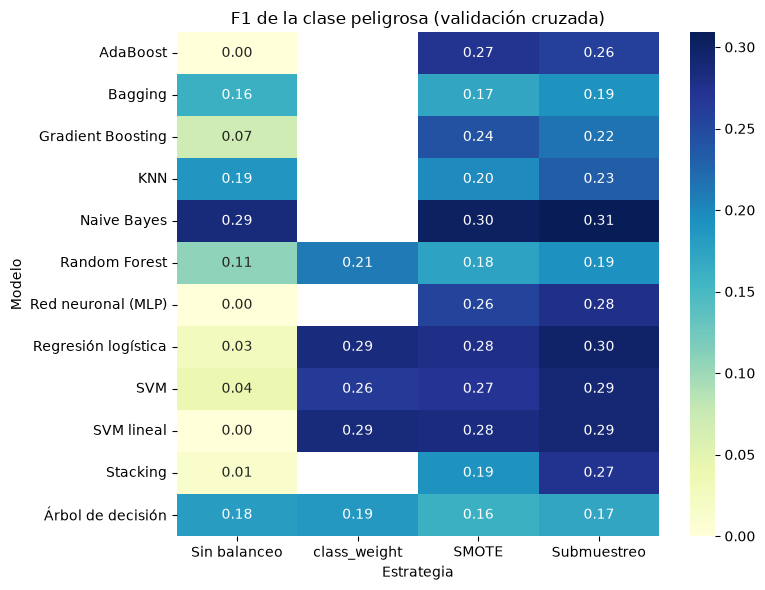

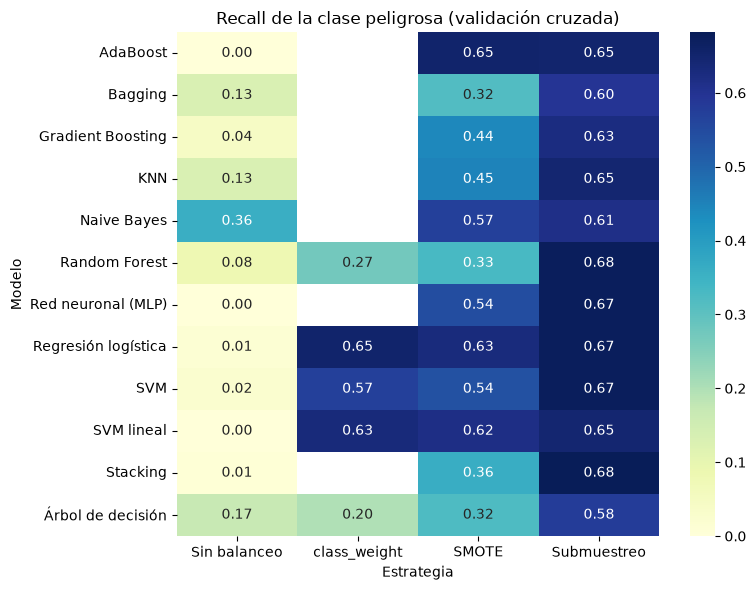

In [12]:
for metrica, nombre_archivo in [('F1', '03_heatmap_f1_modelo_estrategia.png'), ('Recall', '03_heatmap_recall_modelo_estrategia.png')]:
    matriz = tabla_modelos.pivot(index='Modelo', columns='Estrategia', values=metrica)
    matriz = matriz[ESTRATEGIAS]   # dejamos las columnas en el mismo orden de siempre
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title(metrica + ' de la clase peligrosa (validación cruzada)')
    plt.tight_layout()
    plt.savefig(RUTA_FIGURAS + nombre_archivo, bbox_inches='tight', dpi=150)
    plt.show()

**Lo que notamos.** Lo más claro es que **balancear sí importa**. Sin balanceo el F1 promedio de los 12 modelos es 0,090 y el recall promedio apenas 0,080; con submuestreo sube a 0,250 de F1 y 0,645 de recall, con SMOTE a 0,234 y 0,481, y con `class_weight` (solo en 5 modelos) a 0,247 y 0,466. La precisión casi no se mueve entre estrategias (entre 0,154 y 0,179), o sea que balancear nos hace detectar muchos más turnos peligrosos, pero a costa de más falsas alarmas.

Por estrategia, el submuestreo fue la mejor en 8 de los 12 modelos, SMOTE en 2 (AdaBoost y Gradient Boosting) y `class_weight` en 2 (el árbol y el Random Forest). Los modelos que más aprovechan el balanceo son los que sin él se quedan casi en cero: la SVM lineal pasa de 0,000 a 0,291, la red neuronal de 0,000 a 0,277, AdaBoost de 0,000 a 0,272, la regresión logística de 0,028 a 0,298 y la SVM de 0,040 a 0,290. Naive Bayes ya rendía bien sin balancear (0,287) y mejora poco (0,309). En cambio KNN, el árbol, Bagging y el Random Forest ganan poco y se quedan abajo (entre 0,185 y 0,231 en su mejor estrategia), por debajo de los modelos lineales.

Ahora el box plot del F1 de cada partición, como en clase, usando para cada modelo su mejor estrategia. Sirve para ver qué tanto varía el resultado entre particiones y si las diferencias entre modelos son reales o ruido.

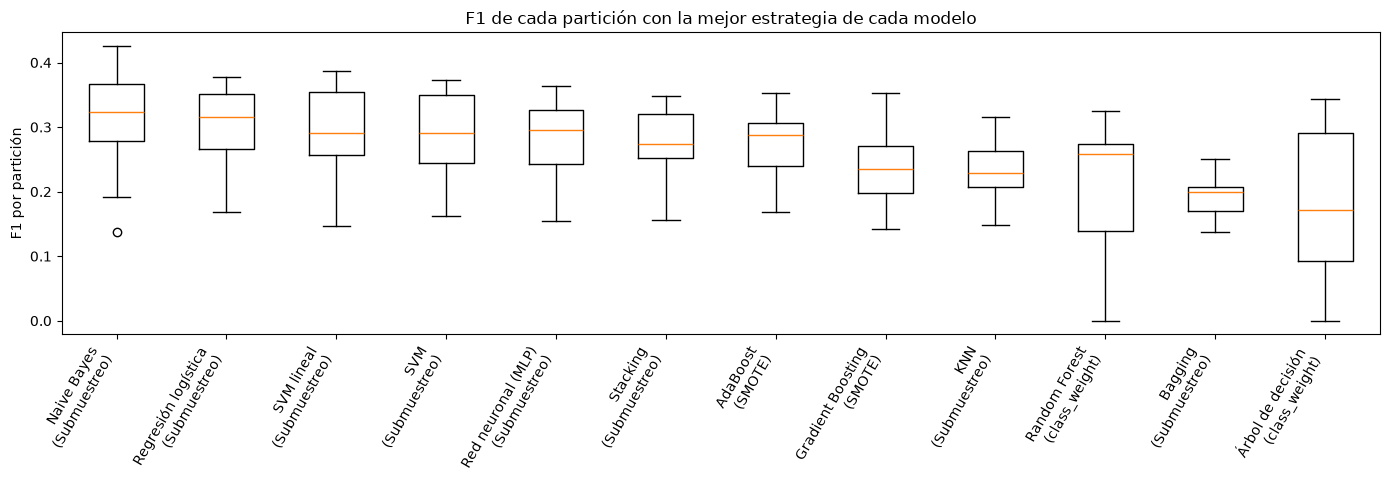

,Modelo,Estrategia,F1,F1_std,Recall,Precision,ROC_AUC
0,Naive Bayes,Submuestreo,0.308999,0.085190,0.614835,0.207434,0.777635
2,Regresión logística,Submuestreo,0.298004,0.068839,0.674725,0.192132,0.780429
3,SVM lineal,Submuestreo,0.291068,0.074230,0.645604,0.188676,0.778131
4,SVM,Submuestreo,0.290413,0.066734,0.674725,0.185905,0.761407
10,Red neuronal (MLP),Submuestreo,0.276769,0.066748,0.674725,0.174637,0.777966
11,Stacking,Submuestreo,0.273667,0.055953,0.681868,0.171838,0.760778
12,AdaBoost,SMOTE,0.272296,0.054307,0.653297,0.172971,0.771356
17,Gradient Boosting,SMOTE,0.242540,0.064732,0.440659,0.169510,0.674870
18,KNN,Submuestreo,0.230789,0.046428,0.646154,0.140951,0.728771
20,Random Forest,class_weight,0.211056,0.099377,0.273626,0.175695,0.722448


In [13]:
# Para cada modelo nos quedamos con su fila de mayor F1 (la tabla ya está ordenada, así que la primera que aparece es la mejor)
mejores_por_modelo = tabla_modelos.drop_duplicates(subset='Modelo')

f1_por_modelo = []
etiquetas = []
for i in range(len(mejores_por_modelo)):
    fila = mejores_por_modelo.iloc[i]
    f1_por_modelo.append(fila['F1_por_particion'])
    etiquetas.append(fila['Modelo'] + '\n(' + fila['Estrategia'] + ')')

plt.figure(figsize=(14, 5))
plt.boxplot(f1_por_modelo)
plt.xticks(range(1, len(etiquetas) + 1), etiquetas, rotation=60, ha='right')
plt.ylabel('F1 por partición')
plt.title('F1 de cada partición con la mejor estrategia de cada modelo')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '03_boxplot_f1_por_particion.png', bbox_inches='tight', dpi=150)
plt.show()

mejores_por_modelo[['Modelo', 'Estrategia', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC']]

**Lo que notamos.** El F1 varía bastante entre particiones: la desviación típica de las 41 combinaciones es de 0,062 en promedio, y en los primeros lugares va de 0,060 a 0,085. La diferencia entre el primer puesto (0,309) y el quinto (0,290) es de solo 0,019, mucho menor que esa desviación. Por eso **no podemos decir que Naive Bayes sea de verdad mejor que la regresión logística, la SVM lineal o la SVM**: con 136 turnos peligrosos en train, las diferencias entre los cinco primeros son ruido. Lo que sí es claro es que forman un grupo por encima de los árboles y los ensambles.

Por último, la gráfica de accuracy contra F1 para mostrar la trampa del accuracy: cada punto es una combinación. Si el accuracy sirviera para decidir, las combinaciones con mayor accuracy tendrían también mayor F1.

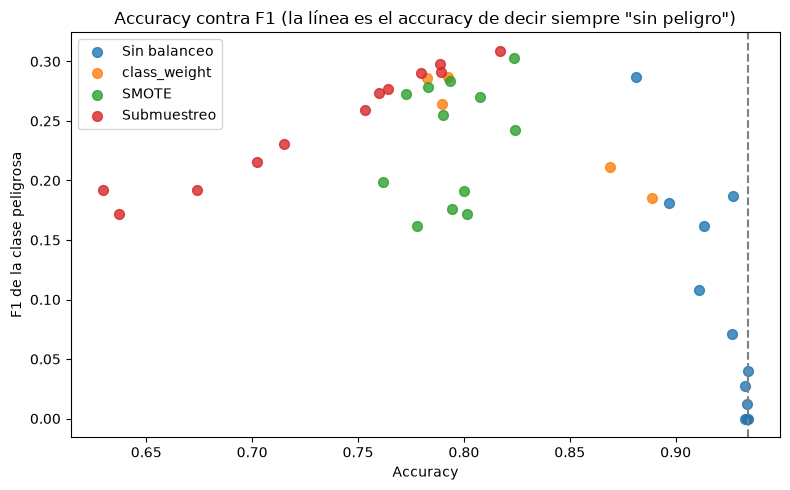

In [14]:
plt.figure(figsize=(8, 5))
for estrategia in ESTRATEGIAS:
    parte = tabla_modelos[tabla_modelos['Estrategia'] == estrategia]
    plt.scatter(parte['Accuracy'], parte['F1'], label=estrategia, s=50, alpha=0.8)
plt.axvline(1 - y_train.mean(), linestyle='--', color='gray')   # el accuracy de decir siempre "sin peligro"
plt.xlabel('Accuracy')
plt.ylabel('F1 de la clase peligrosa')
plt.title('Accuracy contra F1 (la línea es el accuracy de decir siempre "sin peligro")')
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '03_accuracy_vs_f1.png', bbox_inches='tight', dpi=150)
plt.show()

**Lo que notamos.** Aquí se ve la trampa del accuracy. Sin balanceo el accuracy promedio es 0,921 y combinaciones como la SVM lineal, la red neuronal y AdaBoost llegan a 0,933 o 0,934, casi igual que el 0,934 de decir siempre "sin peligro" (la línea punteada), con un F1 de 0,000. En cambio las mejores por F1 tienen un accuracy más bajo: Naive Bayes con submuestreo 0,817, la regresión logística 0,789 y la SVM lineal 0,789, todas por debajo de la línea. Si nos hubiéramos guiado por el accuracy habríamos escogido justo los modelos que no detectan nada.

## Las 3 mejores combinaciones

Los 3 mejores pasan al notebook 04, donde se ajustan sus hiperparámetros. Tomamos las 3 primeras filas de la tabla pero de **modelos distintos**: si el mejor modelo apareciera con dos estrategias, solo contamos la mejor de ellas, para no ajustar dos veces el mismo modelo.

In [15]:
top3 = tabla_modelos.drop_duplicates(subset='Modelo').head(3)
top3[['Modelo', 'Estrategia', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy']]

,Modelo,Estrategia,F1,F1_std,Recall,Precision,ROC_AUC,Accuracy
0,Naive Bayes,Submuestreo,0.308999,0.085190,0.614835,0.207434,0.777635,0.817150
2,Regresión logística,Submuestreo,0.298004,0.068839,0.674725,0.192132,0.780429,0.788551
3,SVM lineal,Submuestreo,0.291068,0.074230,0.645604,0.188676,0.778131,0.789037


## Conclusiones

- **Qué estrategia ayuda más.** Balancear es imprescindible: sin balanceo el F1 promedio es 0,090 y con cualquier estrategia sube a entre 0,234 y 0,250. El submuestreo aleatorio fue la mejor estrategia en 8 de los 12 modelos y la que más recall da (0,645 en promedio). El precio es la precisión, que se queda cerca de 0,16 en promedio: de cada cinco alarmas, cuatro son falsas.
- **Qué modelos aprovechan más el balanceo.** Los lineales y la red neuronal (regresión logística, SVM, SVM lineal, MLP) y AdaBoost pasan de F1 casi 0 a unos 0,27 a 0,30. Los modelos basados en árboles y KNN ganan poco y quedan por debajo.
- **Variación entre particiones.** La desviación del F1 es de 0,06 en promedio, mayor que las diferencias entre los cinco primeros. Los cinco primeros (Naive Bayes, regresión logística, SVM lineal y SVM, casi todos con submuestreo) no se pueden distinguir con estos datos.
- **Las 3 mejores combinaciones (de modelos distintos)** que pasan al notebook 04 son Naive Bayes con submuestreo (F1 0,309), regresión logística con submuestreo (0,298) y SVM lineal con submuestreo (0,291). Ojo: la SVM lineal no tiene `predict_proba`, y la app y el umbral lo necesitan; si gana en el notebook 04, hay que consultarlo con el grupo.
- **Archivo generado.** `resultados/comparacion_modelos.csv` (41 filas) y las figuras `03_*.png`.

**Siguiente paso:** el notebook 04, donde ajustamos los hiperparámetros de estos tres, elegimos el modelo final y su umbral, y lo evaluamos una sola vez en test.